In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Datos corregidos del laboratorio
data = {
    'Medición': [1, 2, 3, 4, 5, 6],
    'P[Kn/m^2]': [230, 230, 210, 200, 30, 30],
    'Q [m^3/min]': [0.12, 0.14, 0.13, 0.13, 0.12, 0.12],
    'Vueltas': [146, 474, 146, 29.87, 49.67, 43],
    'Fuerza [N]': [3, 2.5, 1, 1, 1, 1],
    'Tiempo [seg]': [29.98, 29.87, 29.93, 29.79, 10, 10],
    'Rpm': [292.195, 952.126, 292.683, 60.161, 298, 258],
    'Radio [m]': [0.162, 0.162, 0.162, 0.162, 0.162, 0.162],
    'T [N*m]': [0.485001, 0.4041675, 0.161667, 0.161667, 0.161667, 0.161667],
    'w[rad/s]': [30.599, 99.706, 30.650, 6.300, 31.206, 27.018],
    'Potencia en el eje [W]': [14.840, 40.298, 4.955, 1.019, 5.045, 4.368],
    'P [Pa]': [230000, 230000, 210000, 200000, 30000, 30000],
    'Q [m^3/seg]': [0.002, 0.002, 0.002, 0.002, 0.002, 0.002],
    'Pot. Hidráulica [W]': [460.000, 536.667, 455, 433.333, 60, 60],
    'η_turbina': [3.23, 7.51, 1.09, 0.24, 8.41, 7.28]
}

df = pd.DataFrame(data)

# Convertir porcentajes a valores decimales para cálculos
df['η_turbina'] = df['η_turbina'] / 100

# Separar datos del docente (mediciones 1-4) y estudiantes (mediciones 5-6)
df_docente = df[df['Medición'] <= 4]
df_estudiantes = df[df['Medición'] > 4]

### Gráfico 1: Potencia en el eje vs Potencia Hidráulica

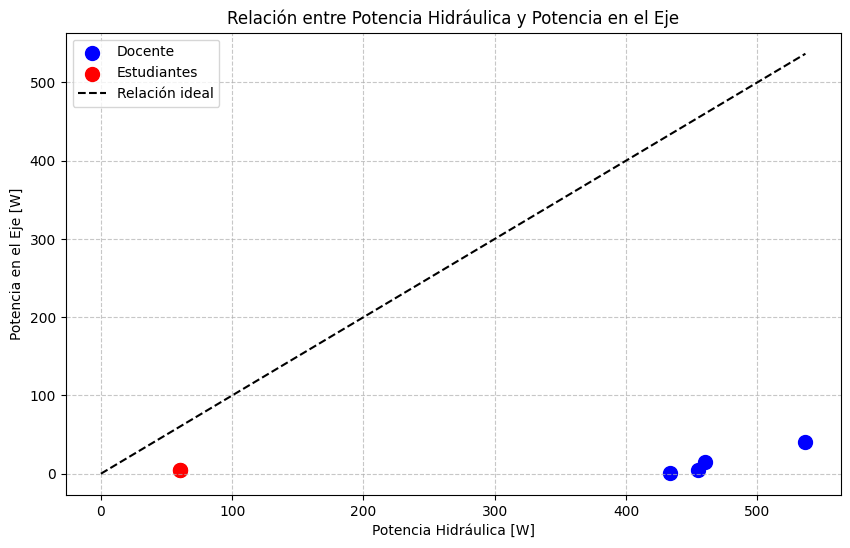

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(df_docente['Pot. Hidráulica [W]'], df_docente['Potencia en el eje [W]'], 
            color='blue', s=100, label='Docente')
plt.scatter(df_estudiantes['Pot. Hidráulica [W]'], df_estudiantes['Potencia en el eje [W]'], 
            color='red', s=100, label='Estudiantes')

# Línea de igualdad (ideal)
max_val = max(df['Pot. Hidráulica [W]'].max(), df['Potencia en el eje [W]'].max())
plt.plot([0, max_val], [0, max_val], 'k--', label='Relación ideal')

plt.xlabel('Potencia Hidráulica [W]')
plt.ylabel('Potencia en el Eje [W]')
plt.title('Relación entre Potencia Hidráulica y Potencia en el Eje')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Gráfico 2: Rendimiento de la turbina por medición

### Gráfico 3: Comparación de potencias y rendimiento

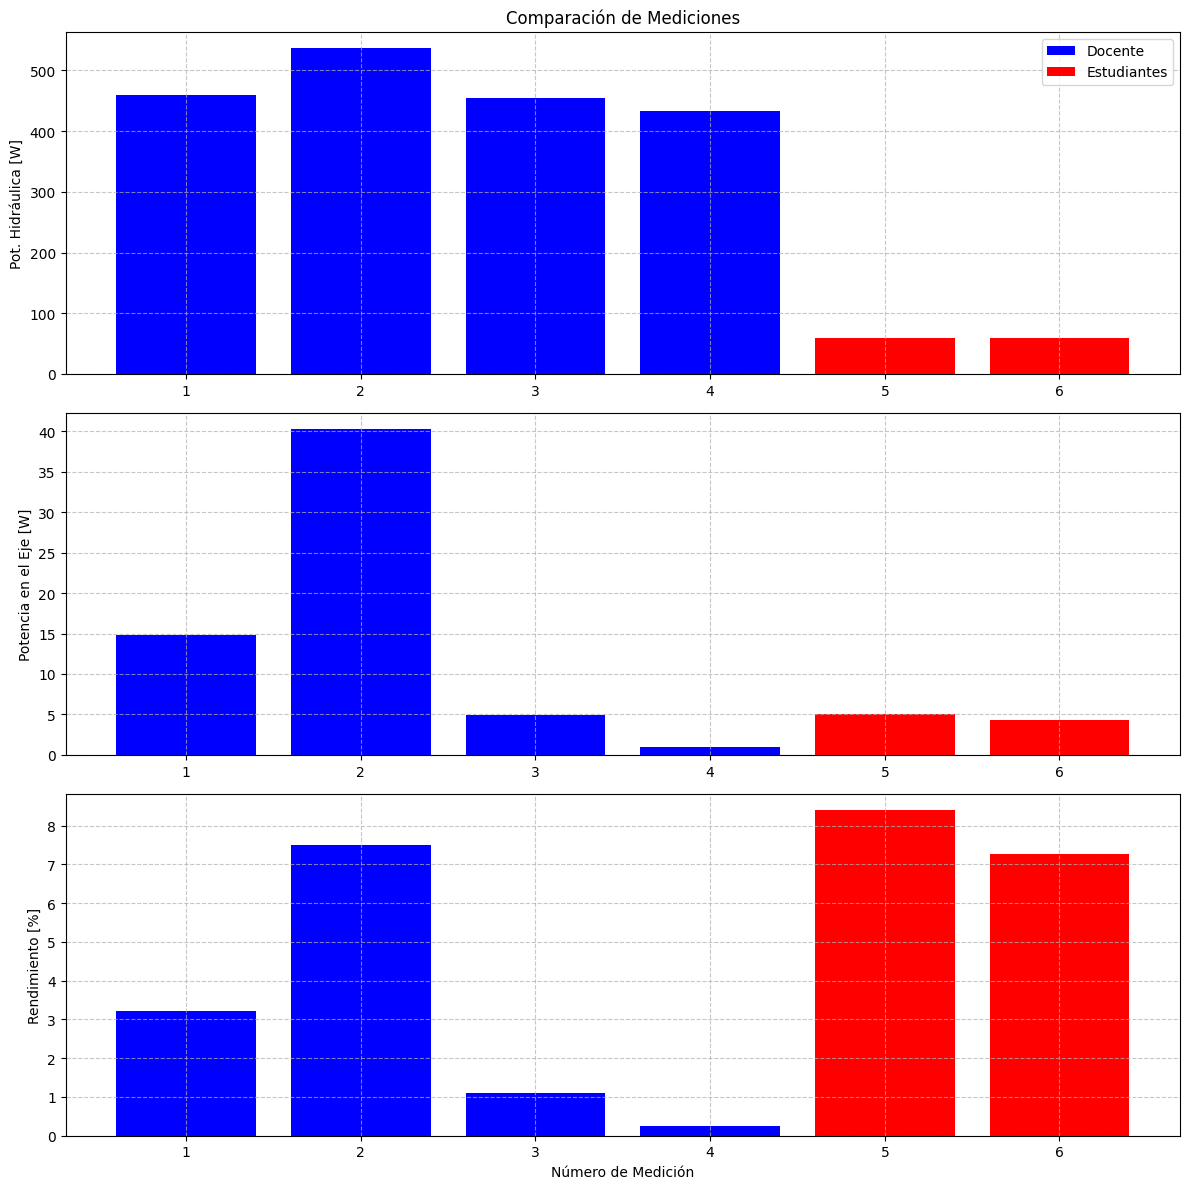

In [15]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12))

# Potencia Hidráulica
ax1.bar(df_docente['Medición'], df_docente['Pot. Hidráulica [W]'], color='blue', label='Docente')
ax1.bar(df_estudiantes['Medición'], df_estudiantes['Pot. Hidráulica [W]'], color='red', label='Estudiantes')
ax1.set_ylabel('Pot. Hidráulica [W]')
ax1.set_title('Comparación de Mediciones')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)
ax1.set_xticks(df['Medición'])

# Potencia en el Eje
ax2.bar(df_docente['Medición'], df_docente['Potencia en el eje [W]'], color='blue')
ax2.bar(df_estudiantes['Medición'], df_estudiantes['Potencia en el eje [W]'], color='red')
ax2.set_ylabel('Potencia en el Eje [W]')
ax2.grid(True, linestyle='--', alpha=0.7)
ax2.set_xticks(df['Medición'])

# Rendimiento
ax3.bar(df_docente['Medición'], df_docente['η_turbina']*100, color='blue')
ax3.bar(df_estudiantes['Medición'], df_estudiantes['η_turbina']*100, color='red')
ax3.set_xlabel('Número de Medición')
ax3.set_ylabel('Rendimiento [%]')
ax3.grid(True, linestyle='--', alpha=0.7)
ax3.set_xticks(df['Medición'])

plt.tight_layout()
plt.show()

### Gráfico 4: Relación entre par (T) y velocidad angular (ω)

C:\Users\felip\AppData\Local\Temp\ipykernel_22648\2401667552.py:16: RuntimeWarning: divide by zero encountered in divide
  y = p / x


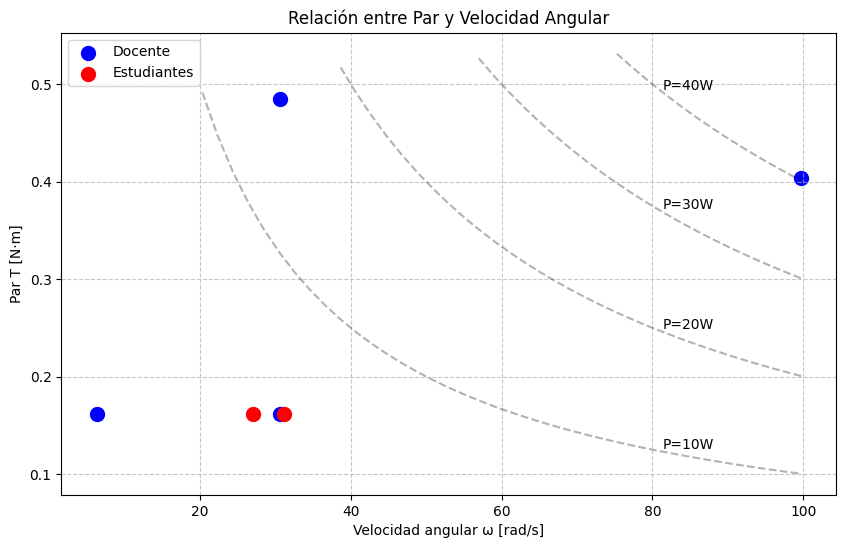

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(df_docente['w[rad/s]'], df_docente['T [N*m]'], 
            color='blue', s=100, label='Docente')
plt.scatter(df_estudiantes['w[rad/s]'], df_estudiantes['T [N*m]'], 
            color='red', s=100, label='Estudiantes')

plt.xlabel('Velocidad angular ω [rad/s]')
plt.ylabel('Par T [N·m]')
plt.title('Relación entre Par y Velocidad Angular')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Añadir ecuación de potencia P = T·ω
x = np.linspace(0, max(df['w[rad/s]']), 50)
for p in [10, 20, 30, 40]:  # Líneas de potencia constante
    y = p / x
    y[y > max(df['T [N*m]'])*1.1] = np.nan  # Limitar el rango visible
    plt.plot(x, y, 'k--', alpha=0.3)
    plt.text(x[-10], y[-10], f'P={p}W', va='bottom')

plt.show()

### Gráfico 5: Eficiencia vs Relación de velocidades

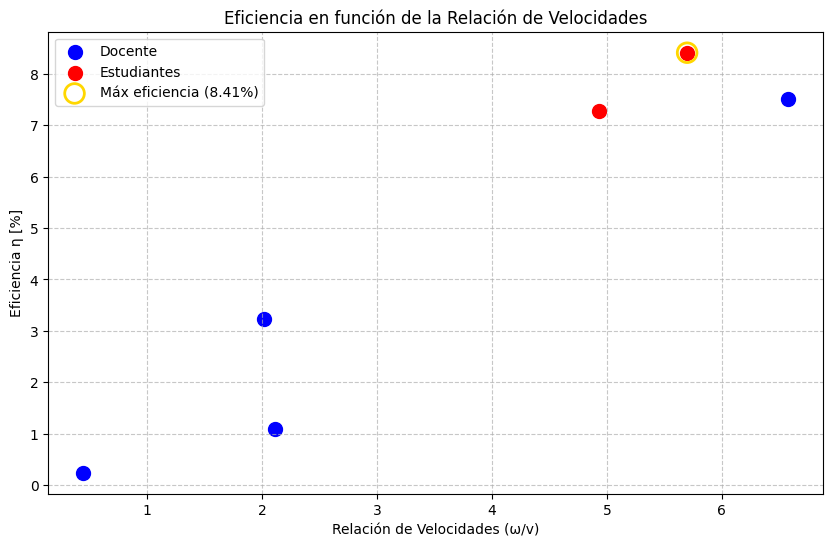

In [17]:
# Calcular relación de velocidades (suponiendo velocidad característica)
v_caracteristica = np.sqrt(df['P[Kn/m^2]']*1000 / 1000)  # sqrt(P/ρ), ρ=1000 kg/m³ para agua
omega_caracteristica = df['Rpm'] * (2*np.pi/60)  # Convertir RPM a rad/s
relacion_velocidades = omega_caracteristica / v_caracteristica

plt.figure(figsize=(10, 6))
plt.scatter(relacion_velocidades[df['Medición'] <= 4], 
            df_docente['η_turbina']*100, 
            color='blue', s=100, label='Docente')
plt.scatter(relacion_velocidades[df['Medición'] > 4], 
            df_estudiantes['η_turbina']*100, 
            color='red', s=100, label='Estudiantes')

plt.xlabel('Relación de Velocidades (ω/v)')
plt.ylabel('Eficiencia η [%]')
plt.title('Eficiencia en función de la Relación de Velocidades')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Resaltar punto de máxima eficiencia
max_eta_idx = df['η_turbina'].idxmax()
plt.scatter(relacion_velocidades[max_eta_idx], df.loc[max_eta_idx, 'η_turbina']*100,
            s=200, facecolors='none', edgecolors='gold', linewidth=2,
            label=f'Máx eficiencia ({df.loc[max_eta_idx, "η_turbina"]*100:.2f}%)')

plt.legend()
plt.show()